# Supervised learning examples

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge

from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Simple Regression Example

In [42]:
# Feature X: Apartment Size in Square Meters (sq. m)
X = np.array([
    [50], [65], [70], [80], [95],
    [100], [110], [125], [130], [145],
    [150], [160]
])

# Target (label) y: Apartment Price (in thousands of dollars)
y = np.array([
    155, 178, 185, 215, 248,
    265, 275, 305, 318, 350,
    355, 375
])

In [43]:
df = pd.DataFrame({
    "Apartment Size (sq. m)": X.flatten(),
    "Apartment Price (thousands $)": y
})

In [44]:
df

,Apartment Size (sq. m),Apartment Price (thousands $)
0,50,155
1,65,178
2,70,185
3,80,215
4,95,248
5,100,265
6,110,275
7,125,305
8,130,318
9,145,350


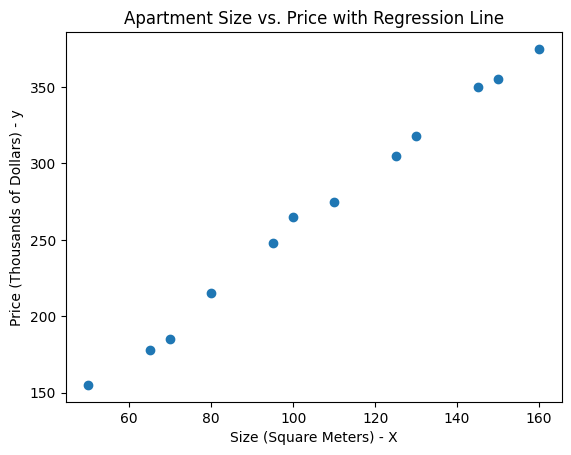

In [45]:
# Plot original data
plt.scatter(X, y, label="Data", colorizer='blue')

plt.title('Apartment Size vs. Price with Regression Line')
plt.xlabel('Size (Square Meters) - X')
plt.ylabel('Price (Thousands of Dollars) - y')
plt.show()

In [46]:
model = BayesianRidge()
model.fit(X, y)

,max_iter,300
,tol,0.001
,alpha_1,1e-06
,alpha_2,1e-06
,lambda_1,1e-06
,lambda_2,1e-06
,alpha_init,None
,lambda_init,None
,compute_score,False
,fit_intercept,True
,copy_X,True


In [47]:
### Find model parameters
m = model.coef_[0]
b = model.intercept_

print(f"Intercept (Base Price): ${b:.2f} thousand")
print(f"Coefficient (Price per sq. meter): ${m:.2f} thousand per sq. m")

Intercept (Base Price): $49.30 thousand
Coefficient (Price per sq. meter): $2.06 thousand per sq. m


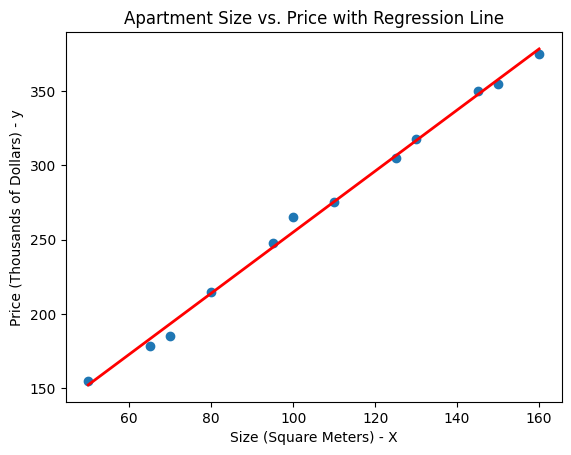

In [48]:
# Create line values
x_line = np.linspace(X.min(), X.max(), 100)
y_line = m * x_line + b

# Plot original data
plt.scatter(X, y, label="Data", colorizer='blue')

# Plot regression line
plt.plot(x_line, y_line, label=f"y = {m:.2f}x + {b:.2f}", linewidth=2, color='red')

plt.title('Apartment Size vs. Price with Regression Line')
plt.xlabel('Size (Square Meters) - X')
plt.ylabel('Price (Thousands of Dollars) - y')
plt.show()

In [49]:
new_size = np.array([[90], [100], [120]]) # 120 sq. meters
y_pred = model.predict(new_size)
y_pred

array([234.38991782, 254.95596713, 296.08806575])

## Simple Classification Example

In [50]:
# Generate a more realistic, overlapping classification dataset
import numpy as np
np.random.seed(42)
n = 120
# Age between 18 and 65
ages = np.random.randint(18, 66, size=n)
# Salary correlated with age but with noise (in dollars)
salaries = np.random.normal(loc=ages * 1000 + 25000, scale=15000).astype(int)
# Compute logit (linear combination) and map to probability with sigmoid
logits = -7 + 0.08 * ages + 0.00008 * salaries
probs = 1.0 / (1.0 + np.exp(-logits))
# Sample labels with noise to create overlapping classes
y = (np.random.rand(n) < probs).astype(int)
X = np.column_stack((ages, salaries))
# Quick check (prints class balance)
print('Samples:', n, ' Class distribution (0,1):', np.bincount(y))

Samples: 120  Class distribution (0,1): [36 84]


In [51]:
df = pd.DataFrame({
    "Age": X[:, 0],
    "Salary": X[:, 1],
    "Label (Bought)": y
})
df

,Age,Salary,Label (Bought)
0,56,78334,1
1,46,64844,1
2,32,74695,1
3,60,71526,1
4,25,62521,1
...,...,...,...
115,26,53187,0
116,25,29451,0
117,29,42423,0
118,51,89180,1


In [52]:
clf = LogisticRegression()
clf.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


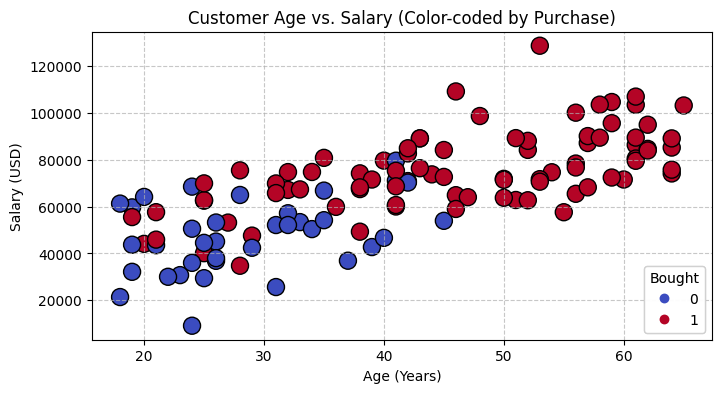

In [54]:
age = X[:, 0]
salary = X[:, 1]

plt.figure(figsize=(8, 4))

scatter = plt.scatter(age, salary, c=y, cmap='coolwarm', s=150, edgecolors='k')

plt.title('Customer Age vs. Salary (Color-coded by Purchase)')
plt.xlabel('Age (Years)')
plt.ylabel('Salary (USD)')

legend1 = plt.legend(*scatter.legend_elements(),
                     title="Bought",
                     loc="lower right")

plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [55]:
age = 56
salary = 78334
probability = clf.predict_proba([[age, salary]])[0][1]

print(f"\nProbability of buying for age {age} and salary ${salary}: {probability:.2f}")



Probability of buying for age 56 and salary $78334: 0.97
